[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decisión:**

Sea:

$$
x_i \ge 0 \quad i = 1, \dots, 6
$$

donde:

- \(x_i\) = kg del ingrediente \(i\)

**Funcion objetivo:**

$$
\min \sum_{i=1}^{6} c_i x_i
$$

**Restricciones:**

Requerimientos nutricionales mínimos:

$$
\sum_{i=1}^{6} a_{ki} x_i \ge r_k
$$

Cotas por ingrediente:

$$
0 \le x_i \le x_i^{\max}
$$

Cantidad total:

$$
I_{\min} \le \sum_{i=1}^{6} x_i \le I_{\max}
$$

### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

In [3]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [7]:
def objetivo_p1(x):
    """Calcula el costo total de la dieta."""
    x = np.asarray(x, dtype=float)
    return float(costos_p1 @ x)


def verificar_p1(x):
    """Verifica si la solucion cumple TODAS las restricciones."""
    x = np.asarray(x, dtype=float)

    nutrientes_totales = nutrientes_p1 @ x   # (4,)
    intake_total = float(np.sum(x))

    tol = 1e-7
    factible = (
        np.all(x >= -tol) and
        np.all(x <= max_kg_p1 + tol) and
        (intake_min_p1 - tol <= intake_total <= intake_max_p1 + tol) and
        np.all(nutrientes_totales >= req_min_p1 - tol)
    )

    return {
        "factible": bool(factible),
        "nutrientes_totales": nutrientes_totales,
        "intake_total": intake_total
    }


def resolver_p1():
    """Resuelve el problema de nutricion animal con LP (linprog)."""
    c = np.asarray(costos_p1, dtype=float)

    # bounds: 0 <= x_i <= max_kg_i
    bounds = [(0.0, float(ub)) for ub in max_kg_p1]

    # linprog usa A_ub x <= b_ub
    A_ub = []
    b_ub = []

    # Nutrientes: nutrientes_p1 @ x >= req_min_p1  ->  -nutrientes_p1 @ x <= -req_min_p1
    A_ub.append(-nutrientes_p1)
    b_ub.append(-req_min_p1)

    # Intake: sum(x) <= intake_max_p1
    A_ub.append(np.ones((1, len(c))))
    b_ub.append(np.array([intake_max_p1], dtype=float))

    # Intake: sum(x) >= intake_min_p1  ->  -sum(x) <= -intake_min_p1
    A_ub.append(-np.ones((1, len(c))))
    b_ub.append(np.array([-intake_min_p1], dtype=float))

    A_ub = np.vstack(A_ub).astype(float)
    b_ub = np.concatenate([np.atleast_1d(bb) for bb in b_ub]).astype(float)

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"linprog no convergio: {res.message}")

    return res.x.astype(float), float(res.fun)

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


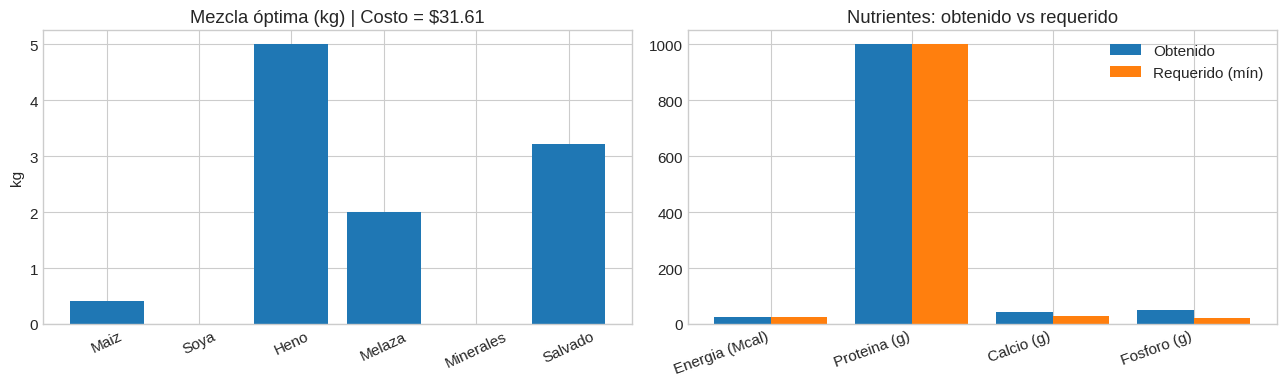

In [22]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion."""
    x_opt = np.asarray(x_opt, dtype=float)
    info = verificar_p1(x_opt)

    nutrientes_totales = info["nutrientes_totales"]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    # Panel 1: kg por ingrediente
    ax[0].bar(nombres_p1, x_opt)
    ax[0].set_title(f"Mezcla óptima (kg) | Costo = ${costo_opt:.2f}")
    ax[0].set_ylabel("kg")
    ax[0].tick_params(axis="x", rotation=25)

    # Panel 2: obtenido vs requerido
    idx = np.arange(len(nombres_nutrientes_p1))
    w = 0.40
    ax[1].bar(idx - w/2, nutrientes_totales, w, label="Obtenido")
    ax[1].bar(idx + w/2, req_min_p1,        w, label="Requerido (mín)")
    ax[1].set_xticks(idx)
    ax[1].set_xticklabels(nombres_nutrientes_p1, rotation=20, ha="right")
    ax[1].set_title("Nutrientes: obtenido vs requerido")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    # Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decisión:**

Sea:

$$
w_i \ge 0 \quad i = 1, \dots, n
$$

donde:

- \(w_i\) = proporción invertida en el activo \(i\)

**Función objetivo:**

Minimizar el riesgo (varianza del portafolio):

$$
\min \; w^\top \Sigma w
$$

donde \(\Sigma\) es la matriz de covarianzas.

**Restricciones:**

Presupuesto total:

$$
\sum_{i=1}^{n} w_i = 1
$$

---

Retorno mínimo requerido:

$$
\sum_{i=1}^{n} \mu_i w_i \ge R_{\min}
$$

donde \(\mu_i\) es el rendimiento esperado.

---

Cotas por activo:

$$
0 \le w_i \le w_i^{\max}
$$

### 2.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

In [10]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [11]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Calcula la varianza (riesgo) del portafolio."""
    w = np.asarray(w, dtype=float)
    return float(w @ cov_p2 @ w)


def verificar_p2(w):
    """Verifica si el portafolio cumple todas las restricciones."""
    w = np.asarray(w, dtype=float)

    rendimiento = float(rendimientos_p2 @ w)
    varianza = float(w @ cov_p2 @ w)
    suma_pesos = float(np.sum(w))

    tol = 1e-7
    factible = (
        np.all(w >= -tol) and
        np.all(w <= max_por_activo_p2 + tol) and
        abs(suma_pesos - 1.0) <= 1e-4 and
        (rendimiento + 1e-6 >= retorno_minimo_p2)
    )

    return {
        "factible": bool(factible),
        "rendimiento": rendimiento,
        "varianza": varianza,
        "suma_pesos": suma_pesos
    }


def resolver_p2():
    """Resuelve el problema de portafolio."""
    n = len(activos_p2)
    w0 = np.ones(n) / n

    constraints = [
        {"type": "eq",   "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: (rendimientos_p2 @ w) - retorno_minimo_p2}
    ]
    bounds = [(0.0, float(max_por_activo_p2)) for _ in range(n)]

    res = minimize(objetivo_p2, x0=w0, constraints=constraints, bounds=bounds, method="SLSQP")
    if not res.success:
        raise RuntimeError(f"minimize falló: {res.message}")

    return res.x.astype(float), float(res.fun)

Solucion P2:
  Bonos gob.: 35.7%
  Acciones tech: 9.9%
  Bienes raices: 27.4%
  Materias primas: 19.4%
  Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Factible: True


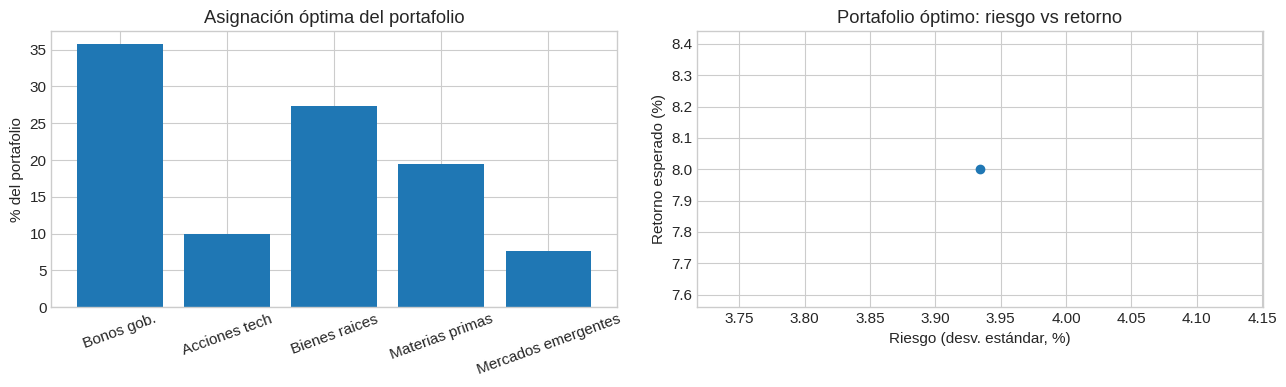

In [23]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio."""
    w_opt = np.asarray(w_opt, dtype=float)

    rendimiento_opt = float(rendimientos_p2 @ w_opt)
    riesgo_opt = float(np.sqrt(varianza_opt))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    # Panel 1: asignación
    ax[0].bar(activos_p2, 100 * w_opt)
    ax[0].set_title("Asignación óptima del portafolio")
    ax[0].set_ylabel("% del portafolio")
    ax[0].tick_params(axis="x", rotation=20)

    # Panel 2: punto riesgo vs retorno
    ax[1].scatter([100 * riesgo_opt], [100 * rendimiento_opt])
    ax[1].set_title("Portafolio óptimo: riesgo vs retorno")
    ax[1].set_xlabel("Riesgo (desv. estándar, %)")
    ax[1].set_ylabel("Retorno esperado (%)")

    plt.tight_layout()
    plt.show()

w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

### Problema 3 – Cobertura de antenas

**Variables de decisión:**

Sea:

$$
y_i =
\begin{cases}
1 & \text{si se selecciona la torre } i \\
0 & \text{si no se selecciona}
\end{cases}
\quad i = 1, \dots, m
$$

**Función objetivo:**

Minimizar el costo total:

$$
\min \sum_{i=1}^{m} c_i y_i
$$

donde \(c_i\) es el costo de la torre \(i\).

**Restricciones:**

Cobertura de zonas:

$$
\sum_{i=1}^{m} a_{ij} y_i \ge 1
\quad \forall j
$$

donde:

- \(a_{ij} = 1\) si cubre la zona \(j\)

---

$$
y_i \in \{0,1\}
$$

### 3.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

In [13]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [14]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas."""
    y = np.asarray(y, dtype=float)
    return float(costos_torres_p3 @ y)


def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas."""
    y = np.asarray(y, dtype=float)

    cobertura_por_zona = cobertura_p3.T @ y  # (10,)
    zonas_cubiertas = [j for j in range(n_zonas_p3) if cobertura_por_zona[j] >= 0.999]
    zonas_sin_cubrir = [j for j in range(n_zonas_p3) if cobertura_por_zona[j] < 0.999]

    return {
        "factible": len(zonas_sin_cubrir) == 0,
        "zonas_cubiertas": zonas_cubiertas,
        "zonas_sin_cubrir": zonas_sin_cubrir
    }


def resolver_p3():
    """Resuelve el problema de cobertura con antenas (MILP)."""
    c = np.asarray(costos_torres_p3, dtype=float)

    # Restricciones por zona: cobertura_p3.T @ y >= 1
    A = cobertura_p3.T.astype(float)  # (10,7)
    lb = np.ones(n_zonas_p3, dtype=float)
    ub = np.full(n_zonas_p3, np.inf, dtype=float)
    constraints = LinearConstraint(A, lb=lb, ub=ub)

    integrality = np.ones(n_torres_p3, dtype=int)  # y enteras
    bounds = Bounds(lb=np.zeros(n_torres_p3), ub=np.ones(n_torres_p3))

    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)
    if not res.success:
        raise RuntimeError(f"milp falló: {res.message}")

    return res.x.astype(float), float(res.fun)

Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


/tmp/ipython-input-1254270553.py:29: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


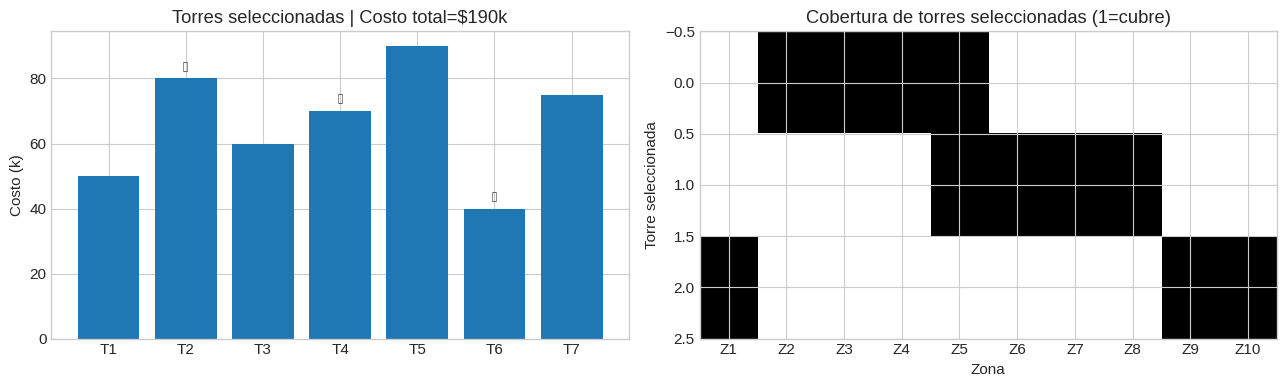

In [26]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura."""
    y_opt = np.asarray(y_opt, dtype=float)
    sel = y_opt > 0.5

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    # Panel 1: torres y selección
    ax[0].bar(nombres_torres_p3, costos_torres_p3)
    ax[0].set_title(f"Torres seleccionadas | Costo total=${costo_opt:.0f}k")
    ax[0].set_ylabel("Costo (k)")
    for i, s in enumerate(sel):
        if s:
            ax[0].text(i, costos_torres_p3[i] + 2, "✓", ha="center")

    # Panel 2: cobertura de torres seleccionadas (heatmap)
    cov_sel = cobertura_p3[sel, :]
    if cov_sel.shape[0] == 0:
        cov_sel = np.zeros((1, n_zonas_p3))
    ax[1].imshow(cov_sel, aspect="auto")
    ax[1].set_title("Cobertura de torres seleccionadas (1=cubre)")
    ax[1].set_xlabel("Zona")
    ax[1].set_ylabel("Torre seleccionada")
    ax[1].set_xticks(np.arange(n_zonas_p3))
    ax[1].set_xticklabels([f"Z{j+1}" for j in range(n_zonas_p3)])

    plt.tight_layout()
    plt.show()

y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

### Problema 4 – Calibración del modelo

**Variables de decisión:**

Sea:

$$
\theta \in \mathbb{R}^k
$$

donde:

- \(\theta\) = parámetros del modelo

**Función objetivo:**

Minimizar el error de ajuste:

$$
\min \sum_{t}
\left(
y_{\text{modelo}}(t;\theta)
-
y_{\text{obs}}(t)
\right)^2
$$

**Restricciones:**

Cotas de parámetros:

$$
\theta_\ell \le \theta \le \theta_u
$$

### 4.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

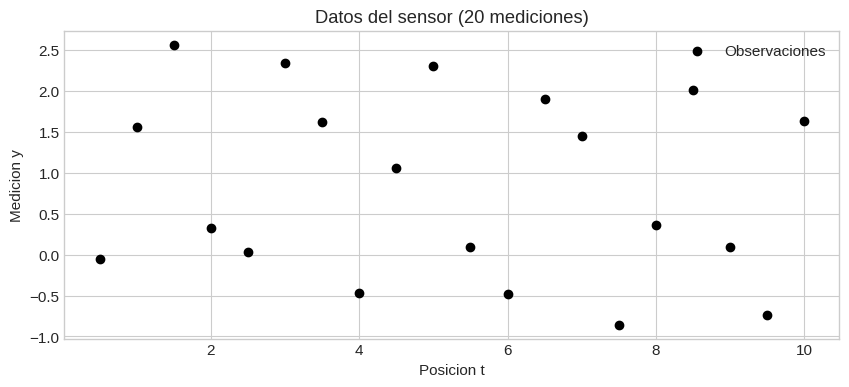

In [16]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [17]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error entre el modelo y las observaciones."""
    params = np.asarray(params, dtype=float)
    y_pred = modelo_sensor(t_obs_p4, params)
    resid = y_pred - y_obs_p4
    return float(np.sum(resid**2))


def resolver_p4():
    """Resuelve el problema de calibracion (DE)."""
    res = differential_evolution(objetivo_p4, bounds=bounds_p4, seed=2026)
    if not res.success:
        raise RuntimeError(f"differential_evolution falló: {res.message}")
    return res.x.astype(float), float(res.fun)

Solucion P4:
  a = 1.5089
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error: 0.088386


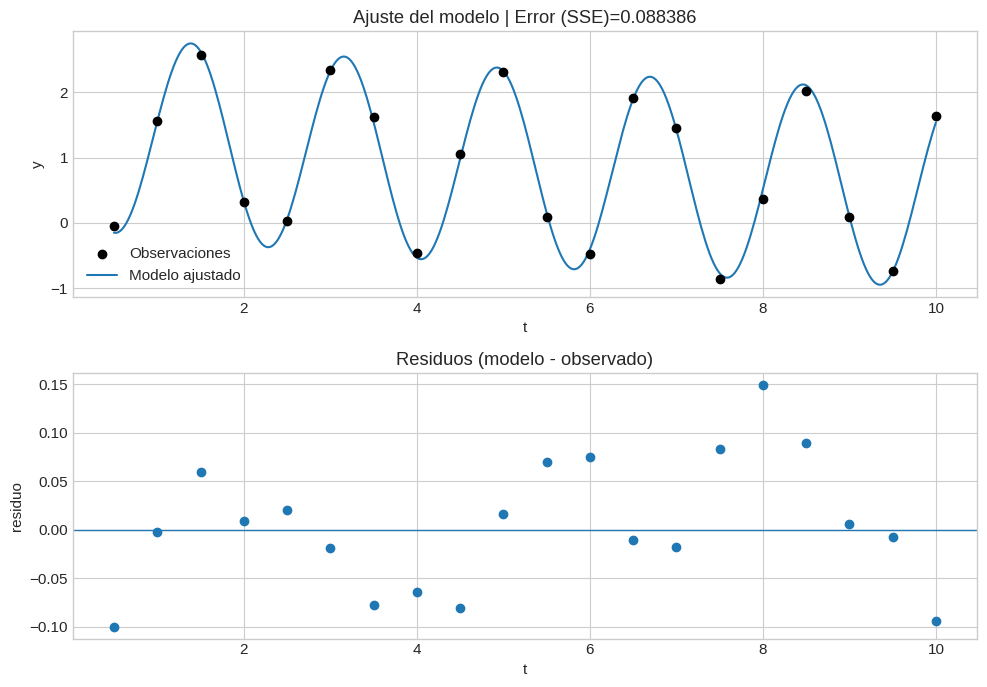

In [18]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """Visualiza el ajuste del modelo a los datos."""
    params_opt = np.asarray(params_opt, dtype=float)

    t_dense = np.linspace(t_obs_p4.min(), t_obs_p4.max(), 400)
    y_fit = modelo_sensor(t_dense, params_opt)

    y_hat = modelo_sensor(t_obs_p4, params_opt)
    resid = y_hat - y_obs_p4

    fig, ax = plt.subplots(2, 1, figsize=(10, 7))

    ax[0].scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
    ax[0].plot(t_dense, y_fit, label="Modelo ajustado")
    ax[0].set_title(f"Ajuste del modelo | Error (SSE)={error_opt:.6f}")
    ax[0].set_xlabel("t")
    ax[0].set_ylabel("y")
    ax[0].legend()

    ax[1].axhline(0.0, linewidth=1)
    ax[1].scatter(t_obs_p4, resid)
    ax[1].set_title("Residuos (modelo - observado)")
    ax[1].set_xlabel("t")
    ax[1].set_ylabel("residuo")

    plt.tight_layout()
    plt.show()


params_opt_p4, error_opt_p4 = resolver_p4()

print(f"Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

### Problema 5 – Red de distribución

**Variables de decisión:**

Sea:

$$
y_i =
\begin{cases}
1 & \text{si se abre el centro } i \\
0 & \text{si no se abre}
\end{cases}
\quad i = 1, \dots, p
$$

$$
X_{ij} \ge 0
$$

donde:

- \(X_{ij}\) = cantidad enviada

**Función objetivo:**

Minimizar el costo total:

$$
\min \sum_{i=1}^{p} f_i y_i
+
\sum_{i=1}^{p} \sum_{j=1}^{q} c_{ij} X_{ij}
$$

**Restricciones:**

Demanda por cliente:

$$
\sum_{i=1}^{p} X_{ij} \ge d_j
\quad \forall j
$$

---

Capacidad por centro:

$$
\sum_{j=1}^{q} X_{ij}
\le
\text{cap}_i \, y_i
\quad \forall i
$$

---

$$
y_i \in \{0,1\}
$$

### 5.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

In [19]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [20]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    """Calcula el costo total: costos fijos + costos de envio."""
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    fijo = float(costos_fijos_p5 @ y)
    envio = float(np.sum(costos_envio_p5 * X))
    return fijo + envio


def verificar_p5(y, X):
    """Verifica si la solucion cumple todas las restricciones."""
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    demanda_cumplida = X.sum(axis=0)  # (6,)
    capacidad_usada = X.sum(axis=1)   # (4,)

    tol = 1e-7
    ok_demanda = np.all(demanda_cumplida + 1e-6 >= demandas_p5)
    ok_cap = np.all(capacidad_usada <= capacidades_p5 * (y + tol) + 1e-6)
    ok_bounds = np.all(X >= -tol) and np.all((y >= -tol) & (y <= 1 + tol))

    return {
        "factible": bool(ok_demanda and ok_cap and ok_bounds),
        "demanda_cumplida": demanda_cumplida,
        "capacidad_usada": capacidad_usada
    }


def resolver_p5():
    """Resuelve el problema de red de distribucion (MILP)."""
    n_y = n_cds_p5
    n_x = n_cds_p5 * n_clientes_p5
    n = n_y + n_x

    # vector de costos para z = [y, vec(X)]
    c = np.zeros(n, dtype=float)
    c[:n_y] = costos_fijos_p5.astype(float)
    c[n_y:] = costos_envio_p5.astype(float).reshape(-1)

    # bounds: y in [0,1], X >= 0
    lb = np.zeros(n, dtype=float)
    ub = np.full(n, np.inf, dtype=float)
    ub[:n_y] = 1.0
    bounds = Bounds(lb=lb, ub=ub)

    # integrality: y enteras (binarias por bounds), X continuas
    integrality = np.zeros(n, dtype=int)
    integrality[:n_y] = 1

    rows = []
    lbs = []
    ubs = []

    # (1) Demanda por cliente: sum_i X_{i,j} >= demanda_j
    for j in range(n_clientes_p5):
        row = np.zeros(n, dtype=float)
        for i in range(n_cds_p5):
            row[n_y + i*n_clientes_p5 + j] = 1.0
        rows.append(row)
        lbs.append(float(demandas_p5[j]))
        ubs.append(np.inf)

    # (2) Capacidad por CD: sum_j X_{i,j} <= capacidad_i * y_i
    #     sum_j X_{i,j} - capacidad_i*y_i <= 0
    for i in range(n_cds_p5):
        row = np.zeros(n, dtype=float)
        row[i] = -float(capacidades_p5[i])
        for j in range(n_clientes_p5):
            row[n_y + i*n_clientes_p5 + j] = 1.0
        rows.append(row)
        lbs.append(-np.inf)
        ubs.append(0.0)

    A = np.vstack(rows)
    constraints = LinearConstraint(A, lb=np.array(lbs), ub=np.array(ubs))

    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)
    if not res.success:
        raise RuntimeError(f"milp falló: {res.message}")

    z = res.x.astype(float)
    y_opt = z[:n_y]
    X_opt = z[n_y:].reshape(n_cds_p5, n_clientes_p5)
    return y_opt, X_opt, float(res.fun)

Solucion P5:
  CDMX: ABIERTO (480/600 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C4: 80 unidades
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 70 unidades
    -> Cliente C5: 100 unidades
    -> Cliente C6: 180 unidades
Costo total: $5130k
Factible: True


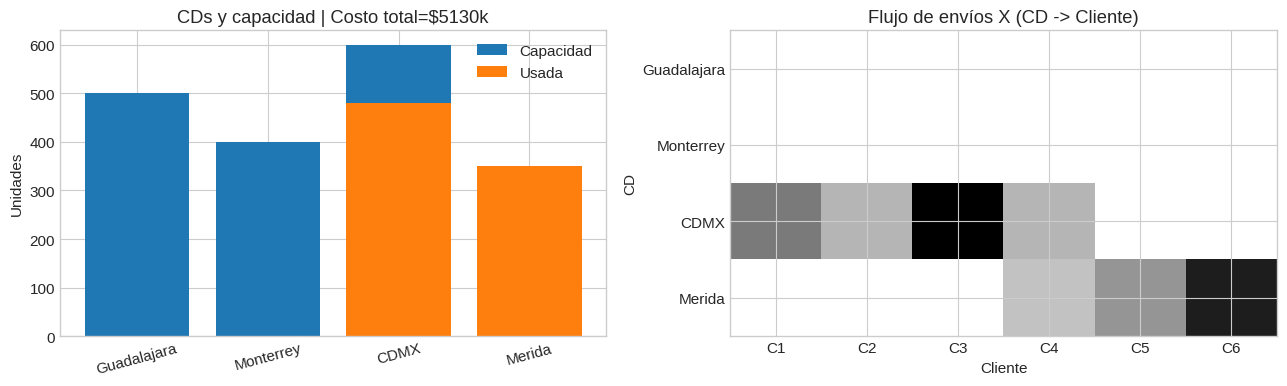

In [21]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    """Visualiza la red de distribucion."""
    y_opt = np.asarray(y_opt, dtype=float)
    X_opt = np.asarray(X_opt, dtype=float)

    cap_usada = X_opt.sum(axis=1)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    # Panel 1: capacidad usada vs disponible (por CD)
    ax[0].bar(ciudades_p5, capacidades_p5, label="Capacidad")
    ax[0].bar(ciudades_p5, cap_usada, label="Usada")
    ax[0].set_title(f"CDs y capacidad | Costo total=${costo_opt:.0f}k")
    ax[0].set_ylabel("Unidades")
    ax[0].tick_params(axis="x", rotation=15)
    ax[0].legend()

    # Panel 2: heatmap de envíos
    ax[1].imshow(X_opt, aspect="auto")
    ax[1].set_title("Flujo de envíos X (CD -> Cliente)")
    ax[1].set_xlabel("Cliente")
    ax[1].set_ylabel("CD")
    ax[1].set_xticks(np.arange(n_clientes_p5))
    ax[1].set_xticklabels([f"C{j+1}" for j in range(n_clientes_p5)])
    ax[1].set_yticks(np.arange(n_cds_p5))
    ax[1].set_yticklabels(ciudades_p5)

    plt.tight_layout()
    plt.show()


y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print(f"Solucion P5:")
for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
    if abierto > 0.5:
        cap_usada = X_opt_p5[i].sum()
        print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
        for j in range(n_clientes_p5):
            if X_opt_p5[i, j] > 0.1:
                print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)